In [ ]:
# ============================================================
# 03_eval.ipynb
# Random Subsampling Evaluation
#
# Purpose:
# Evaluate the fine-tuned Wav2Vec2 dementia classifier
# using the original random audio chunk sampling strategy.
#
# Important:
# - Audio segments are randomly sampled at evaluation time.
# - No deterministic seed is enforced for subsampling.
# - Results may vary slightly between runs.
#
# This notebook reproduces the original stochastic pipeline
# prior to introducing a fixed baseline.
# ============================================================

In [1]:
import numpy as np
import pandas as pd

from pathlib import Path
from tqdm import tqdm

import torch
import torchaudio

import os
import sys

from datasets import load_dataset
from transformers import AutoConfig, Wav2Vec2FeatureExtractor

from sklearn.metrics import classification_report

In [2]:
# Mount Google Drive to access prepared datasets.
# All CSVs and audio files live inside the project directory.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load the prepared dataset created in 01_prepare_data.
# At this stage, we are working with structured paths and labels.
from datasets import load_dataset

data_files = {
    'train': '/content/drive/My Drive/CS7357_Project/data/train_dm.csv',
    'valid': '/content/drive/My Drive/CS7357_Project/data/valid_dm.csv'
    }

dataset = load_dataset("csv", data_files=data_files, delimiter="\t", )
train_data = dataset['train']
valid_data = dataset['valid']

print(train_data)
print(valid_data)

Generating train split: 0 examples [00:00, ? examples/s]

Generating valid split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['file', 'label', 'path'],
    num_rows: 193
})
Dataset({
    features: ['file', 'label', 'path'],
    num_rows: 41
})


In [14]:
test_data = valid_data

In [32]:

# Apply Random Audio Subsampling
# Converts file paths to waveform arrays.
# A random chunk of fixed duration is selected per file.
# Because no seed is fixed, repeated runs may produce
# slightly different sampled segments.

test_data = test_data.map(speech_to_array)


Map:   0%|          | 0/41 [00:00<?, ? examples/s]

In [15]:
# Specifies which dataset columns represent
# audio input paths and class labels.
input_col = 'path'
output_col = 'label'

In [31]:
# Ensures label order matches the trained model's
# classification head.
label_list = train_data.unique(output_col)
label_list.sort()
num_classes = len(label_list)
print(f"Number of classes: {num_classes}")
print(f"Classes: {label_list}")

Number of classes: 2
Classes: ['dementia', 'nodementia']


In [18]:
num_labels=num_classes,
label2id={label: i for i, label in enumerate(label_list)},
id2label={i: label for i, label in enumerate(label_list)},

In [19]:
from dataclasses import dataclass
from typing import Optional, Tuple
import torch
from transformers.file_utils import ModelOutput
# Defines structured output compatible with HuggingFace
# evaluation utilities.
@dataclass
class SpeechClassifierModelOutput(ModelOutput):
    loss: Optional[torch.FloatTensor] = None
    logits: torch.FloatTensor = None
    hidden_states: Optional[Tuple[torch.FloatTensor]] = None
    attentions: Optional[Tuple[torch.FloatTensor]] = None

In [20]:
import torch
import torch.nn as nn
from transformers.models.wav2vec2.modeling_wav2vec2 import (Wav2Vec2PreTrainedModel, Wav2Vec2Model)

class Wav2Vec2ClassificationHead(nn.Module):
    """head for wav2vec classification task"""
    def __init__(self, config):
        super().__init__()
        self.dense = nn.Linear(config.hidden_size, config.hidden_size)
        self.dropout = nn.Dropout(config.final_dropout)
        self.out_proj = nn.Linear(config.hidden_size, config.num_labels)

    def forward(self, features, **kwargs):
        x = features
        x = self.dense(x)
        x = self.dropout(x)
        x = torch.tanh(x)
        x = self.dropout(x)
        x = self.out_proj(x)
        return x

class Wav2Vec2ForSpeechClassification(Wav2Vec2PreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.pooling_mode = config.pooling_mode
        self.config = config

        self.wav2vec2 = Wav2Vec2Model(config)
        self.classifier = Wav2Vec2ClassificationHead(config)

        self.init_weights()

    def freeze_feature_extractor(self):
        self.wav2vec2.feature_extractor._freeze_parameters()

    def merge_strategy(self, hidden_states, mode="mean"):
        if mode == "mean":
            return torch.mean(hidden_states, dim=1)
        elif mode == "max":
            return torch.max(hidden_states, dim=1)[0]
        elif mode == "sum":
            return torch.sum(hidden_states, dim=1)
        else:
            raise ValueError(f"Unknown merge strategy: {mode}")

    def forward(
        self,
        input_values,
        attention_mask=None,
        output_attentions=None,
        output_hidden_states=None,
        return_dict=None,
        labels=None,
    ):
        return_dict = return_dict if return_dict is not None else self.config.use_return_dict
        outputs = self.wav2vec2(input_values,
                            attention_mask=attention_mask,
                            output_attentions=output_attentions,
                            output_hidden_states=output_hidden_states,
                            return_dict=return_dict)

        hidden_states = outputs[0]
        hidden_states = self.merge_strategy(hidden_states, self.pooling_mode)
        logits = self.classifier(hidden_states)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))

        if not return_dict:
            output = (logits,) + outputs[2:]
            return ((loss,) + output) if loss is not None else output

        return SpeechClassifierModelOutput(loss=loss, logits=logits, hidden_states=outputs.hidden_states, attentions=outputs.attentions)

In [21]:
# Use GPU if available for faster inference.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [22]:
import torch
from transformers import AutoConfig, AutoFeatureExtractor, AutoModelForAudioClassification

device = "cuda" if torch.cuda.is_available() else "cpu"

model_name_or_path = "Mrsmetamorphosis/wav2vec2-large-xls-r-300m-dm32-baseline-v1"

config = AutoConfig.from_pretrained(
    model_name_or_path,
    trust_remote_code=True
)

feature_extractor = AutoFeatureExtractor.from_pretrained(
    model_name_or_path,
    trust_remote_code=True
)

model = AutoModelForAudioClassification.from_pretrained(
    model_name_or_path,
    config=config,
    trust_remote_code=True
).to(device)

model.eval()

print("Loaded:", model.__class__)
print("Device:", next(model.parameters()).device)

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: Mrsmetamorphosis/wav2vec2-large-xls-r-300m-dm32-baseline-v1
Key                        | Status     | 
---------------------------+------------+-
classifier.out_proj.bias   | UNEXPECTED | 
classifier.dense.bias      | UNEXPECTED | 
classifier.dense.weight    | UNEXPECTED | 
classifier.out_proj.weight | UNEXPECTED | 
classifier.bias            | MISSING    | 
projector.weight           | MISSING    | 
classifier.weight          | MISSING    | 
projector.bias             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded: <class 'transformers.models.wav2vec2.modeling_wav2vec2.Wav2Vec2ForSequenceClassification'>
Device: cuda:0


In [23]:
# Loads raw audio and applies random chunk sampling.
def speech_to_array(batch):
    speech, sr = torchaudio.load(batch["path"])
    transform = torchaudio.transforms.Resample(sr, 16000)
    speech = transform(speech)[0].numpy().squeeze()
    batch["speech"] = speech
    #return random_subsample(speech, max_length=8)
    return batch

def predict(batch):
    features = feature_extractor(batch["speech"], sampling_rate=feature_extractor.sampling_rate, return_tensors="pt", padding=True)

    input_values = features.input_values.to(device)

    with torch.no_grad():
        logits = model(input_values).logits

    pred_ids = torch.argmax(logits, dim=-1).detach().cpu().numpy()
    batch["predicted"] = pred_ids
    return batch

In [25]:
# Performs batched prediction across the validation set.
result = test_data.map(predict, batched=True, batch_size=8)

Parameter 'function'=<function predict at 0x797ac88a5bc0> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only showed once. Subsequent hashing failures won't be showed.


Map:   0%|          | 0/41 [00:00<?, ? examples/s]

In [26]:
label_list

['dementia', 'nodementia']

In [27]:
# Converts label names to numeric IDs for evaluation.
y_true = [config.label2id[name] for name in result["label"]]
y_pred = result["predicted"]

y_true_labels = result["label"]
y_pred_labels = [config.id2label[id] for id in y_pred]

print(y_true)
print(y_pred)

for i in range(len(y_true)):
    if y_pred_labels[i] == y_true_labels[i]:
        print(f"{y_true_labels[i]} -> {y_pred_labels[i]}")

from sklearn.metrics import accuracy_score

accuracy_score(y_true, y_pred)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Column([0, 0, 0, 1, 0])
dementia -> dementia
dementia -> dementia
dementia -> dementia
dementia -> dementia
dementia -> dementia
dementia -> dementia
dementia -> dementia
dementia -> dementia
dementia -> dementia
dementia -> dementia
dementia -> dementia
dementia -> dementia
dementia -> dementia
dementia -> dementia
nodementia -> nodementia
nodementia -> nodementia
nodementia -> nodementia
nodementia -> nodementia
nodementia -> nodementia
nodementia -> nodementia


0.4878048780487805

In [28]:
# Visualizes performance across classes.
# Rows represent actual labels.
# Columns represent predicted labels.
from sklearn.metrics import confusion_matrix
cf_matrix = confusion_matrix(y_true_labels, y_pred_labels, labels=label_list)
cf_matrix

array([[14,  6],
       [15,  6]])

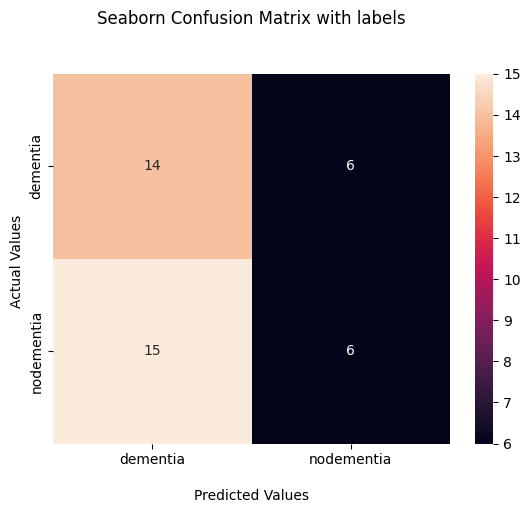

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib_inline as mpl

cm = pd.DataFrame(cf_matrix, index = [i for i in label_list], columns = [i for i in label_list])
ax = sns.heatmap(cm, annot=True)

ax.set_title('Seaborn Confusion Matrix with labels\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

## Display the visualization of the Confusion Matrix.
plt.show()

In [30]:
# Displays precision, recall, F1-score, and support.
#
# Because audio subsampling is random, results may vary
# slightly between evaluation runs.
print(classification_report(y_true, y_pred, target_names=label_list))

              precision    recall  f1-score   support

    dementia       0.48      0.70      0.57        20
  nodementia       0.50      0.29      0.36        21

    accuracy                           0.49        41
   macro avg       0.49      0.49      0.47        41
weighted avg       0.49      0.49      0.46        41



In [ ]:
# ============================================================
# Random Baseline Summary
#
# This evaluation preserves the original stochastic
# subsampling strategy.
#
# A separate deterministic baseline notebook will be used
# for controlled SpecAugment comparison.
# ============================================================